In [1]:
import torch
from torch import nn
import torch_geometric
from torch_geometric.nn import SAGEConv, GraphConv, GraphSAGE
import torch
import networkx as nx 
from torch.utils.data import Dataset, DataLoader
import pickle
import pdb 
import numpy as np
from torch_geometric.data import Data
import networkx as nx
import numpy as np
import pandas as pd 
import pickle
import pdb
from torch_geometric.loader import DataLoader
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.utils import to_dense_adj, subgraph, k_hop_subgraph
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'tools'))
sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'sim'))
from sklearn.neighbors import kneighbors_graph
from torch.optim.lr_scheduler import ReduceLROnPlateau
from ClassGraphDat import GraphDataset
torch.manual_seed(42)

In [2]:
class GraphEncoderWithResidual(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GraphEncoderWithResidual, self).__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels*4, flow='target_to_source', root_weight=False)
        self.conv2 = SAGEConv(hidden_channels*4, hidden_channels*2, flow='target_to_source', root_weight=False)
        self.conv3 = SAGEConv(hidden_channels*2, hidden_channels, flow='target_to_source', root_weight=False)
        self.lin1 = nn.Linear(hidden_channels, int(hidden_channels/2))
        self.lin2 = nn.Linear(int(hidden_channels/2), out_channels)
        # Linear transformation to match dimensions for residual connection
        self.shortcut = nn.Linear(in_channels, out_channels)
        # self.sm = nn.Softmax(dim=1)

    def forward(self, x, edge_index):
        identity = x
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = self.conv3(x, edge_index)
        x = F.dropout(F.relu(self.lin1(x)), p=0.5)
        x = self.lin2(x)
        # Applying shortcut and adding it to the output of conv3
        identity = self.shortcut(identity)
        x += identity  # Element-wise addition
        # x = self.sm(x)
        return x

In [3]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)  # Prevents nans when the loss is zero
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        return torch.mean(F_loss)

focal_loss = FocalLoss(alpha=0.25, gamma=2.0)

# Assuming a loss function appropriate for node feature reconstruction, e.g., MSE for continuous features
def loss_function(reconstructed_x, original_x):

    # print(/)
    # bce_loss_fn = torch.nn.BCEWithLogitsLoss()
    # loss = bce_loss_fn(logits, one_hot_targets)
    # [  2204787.0/14022   ,2204787.0/35079,  2204787.0/780448 ,2204787.0/1375238]
    # weights = torch.tensor([ 662843/17722.0,  662843/49808.0, 662843/209018.0, 662843/386295.0], dtype=torch.float)
    # weights = torch.tensor([  2204787.0/14022   ,2204787.0/35079,  2204787.0/780448 ,2204787.0/1375238], dtype=torch.float)
    total = 1.0#2204689.0
    # arr = [1410221,  794468] 
    arr = [1.0, 1.0]
    weights = torch.tensor([total/a for a in arr], dtype = torch.float)
    
    weights = weights/torch.sum(weights)
    # return F.cross_entropy(reconstructed_x, original_x, weight=weights, label_smoothing=0.2)
    # return F.cross_entropy(reconstructed_x, original_x, label_smoothing=0.4)
    return F.cross_entropy(reconstructed_x, original_x, weight=weights)
    # return F.cross_entropy(reconstructed_x, original_x)#/scale#, label_smoothing=0.4)   

# bce_loss_fn = torch.nn.BCEWithLogitsLoss()
# loss = bce_loss_fn(logits, one_hot_targets)
# print(loss) 

def cosine_loss(adj, emb):
    norms = torch.norm(emb, p=2, dim=1, keepdim=True)
    normalized_embeddings = emb / norms.clamp(min=1e-4)
    cosine_similarity_matrix = torch.mm(normalized_embeddings, normalized_embeddings.t())
    target_adjacency = torch.zeros_like(cosine_similarity_matrix)
    target_adjacency[adj[0], adj[1]] = 1
    # Directly using logits; no need to apply sigmoid.
    return F.binary_cross_entropy_with_logits(cosine_similarity_matrix, target_adjacency)

In [19]:
# def train(model, data_loader, optimizer, device):
#     model.train()
#     total_loss = 0
#     embeddings = []
#     # origs = []
#     # lossfunc = nn.CrossEntropyLoss()
#     # print(data_loader)
#     for feat, edge, _, _ in data_loader:
#         optimizer.zero_grad()
#         # pdb.set_trace()
#         # print(np.shape(feat), np.shape(edges))
#         # print('in main: ', np.shape(feat), np.shape(edges))
#         features = feat.squeeze_(0).to(device)
#         edges = edge.squeeze_(0).to(device)
#         embed = model(features, edges)
#         loss = loss_function(e)
#         # origs.append(data[0][0].detach())
#         # print(np.shape(embed), np.shape(data[2][0]))
#         # print()
#         # print(data[2][0][0], embed[0].detach())
#         # loss = lossfunc(embed, data[2][0].to(device))
#         # print(np.shape(embed), np.shape(data[2][0]), np.shape(data[0][0]), np.shape(data[1][0]))
#         # loss = loss_function(embed, data[2][0].to(device)) #cosine_loss(data[1][0].to(device), embed)
#         loss = cosine_loss(edges, embed)
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()
#         embeddings.append(embed.detach())
#         # print(total_loss)
#     return total_loss / len(data_loader), embeddings#, origs

TIME_LIMIT =  200

def round_function(x, d):
    new = []
    for r in x:
        new.append(np.round(r,decimals=d))
    # pdb.set_trace()
    return tuple(new)

def get_class(m, dat):
    arr = []
    for d in dat:
        # pdb.set_trace()
        assert len(m[tuple(round_function(d.tolist(), 3))]) > 0
        a = np.mean(m[tuple(round_function(d.tolist(), 3))])
        
        if a > TIME_LIMIT:
            arr.append(0)
        else:
            arr.append(1)

    try:
        retVal = torch.tensor(arr, dtype=torch.long)
        return retVal
    except:
        pdb.set_trace()
    
def train(model, data_loader, optimizer, device, meta):
    model.train()
    total_loss = 0
    embeddings = []
    origs = []
    # lossfunc = nn.CrossEntropyLoss()
    # print(data_loader)
    printlosses = []
    for nodes, edges, _ in data_loader:
        optimizer.zero_grad()
        # pdb.set_trace()
        # print(np.shape(nodes), np.shape(edges), nodes, edges)
        n = nodes.squeeze_(0)
        e = edges.squeeze_(0)
        class_now = get_class(meta, n)
        # print(np.shape(nodes), np.shape(edges), np.shape(class_now))
        try:
            if n.dim() == 1:
                n = n.unsqueeze(1)
        
            embed = model(n.to(device), e.to(device))
        except Exception as e:
            pdb.set_trace()
        # print(len(data[0][0]))
        # pdb.set_trace()
        # print(np.shape(class_now), class_now)
        # if np.mean(class_now.tolist()) < 0.01:
        #     pdb.set_trace()
        loss = loss_function(embed, class_now.to(device)) #cosine_loss(data[1][0].to(device), embed)
        # loss = focal_loss(embed, data[2][0].to(device)) #cosine_loss(data[1][0].to(device), embed)
        loss.backward()
        optimizer.step()
        total_loss += loss.detach().item()
        printlosses.append(loss.detach().item())
        if len(printlosses)%10000 == 0:
            printlosses = printlosses[-10000:]
            print(np.sum(printlosses)/10000.0)
        # embeddings.append(embed.detach())
        # print(total_loss)/10.0
    return total_loss / len(data_loader), embeddings, origs

In [20]:
folder_graph = './timeclasses/'
device = "cpu"
# fname = 'small_graphs.pth'
files = os.listdir(folder_graph)
files = [file for file in files if file.endswith('.pickle')]
hC = 80
inC = 40
outchannels = 2

In [ ]:

fil2 = open('alltime.pickle', 'rb')
meta = pickle.load(fil2)
fil2.close()



In [21]:


dataset = GraphDataset(folder_graph, files)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=8)
actuals = []
final_loss = []
embeddings = []
model = GraphEncoderWithResidual(in_channels=inC, hidden_channels=hC, out_channels=outchannels).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
# scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=3, verbose=True)
losses = []
embeds = []
acts = []


In [22]:


for epoch in range(1, 3):  # Number of epochs
    loss, embed, orig = train(model, dataloader, optimizer, device, meta)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
    # scheduler.step(loss)
# epoch_loss = loss / len(dataloader)
# embeddings.append(embeds)
# final_loss.append(losses)
# actuals.append(acts)
model.eval()
# Assuming encoder and decoder are your model's components
encoder_state_dict = model.state_dict()
# decoder_state_dict = model.decoder.state_dict()
# Save the state dictionaries
torch.save(encoder_state_dict, './TEST200time_2classClass_encoder_state_dict'+str(outchannels)+'.pth')
# torch.save(decoder_state_dict, './CDC/decoder_state_dict'+str(outchannels)+'.pth')
        # print(np.shape(embed), np.shape(data[2][0]), np.shape(data[0][0]), np.shape(data[1][0]))


0.3508333066771505
0.3062606028943555
0.3009262382048764


KeyboardInterrupt: 

In [43]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(1, 3):  # Number of epochs
    loss, embed, orig = train(model, dataloader, optimizer, device, meta)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
model.eval()
encoder_state_dict = model.state_dict()
torch.save(encoder_state_dict, './200time_2classClass_encoder_state_dict'+str(outchannels)+'.pth')


0.0
1.806195903952812e-12
4.406506409759814e-14
0.0
0.0
0.0
0.0
0.0
3.1536848132951433e-14
Epoch 1, Loss: 0.0000
5.744566777821092e-12
1.6183962614491065e-12
4.6892520089159e-12
0.0
4.258633268250378e-12
0.0
4.795758012932083e-13
5.057361640581349e-13
0.0
Epoch 2, Loss: 0.0000


In [29]:
optimizer = optim.Adam(model.parameters(), lr=0.0001)

for epoch in range(1, 3):  # Number of epochs
    loss, embed, orig = train(model, dataloader, optimizer, device, meta)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
model.eval()
encoder_state_dict = model.state_dict()
torch.save(encoder_state_dict, './200time_2classClass_encoder_state_dict'+str(outchannels)+'.pth')

0.4339641969427932
0.4296494783220813
0.43322647804375736
0.43343773667444474
0.42919465155112557
0.4339327777516097
0.4289793953614775
0.4283125705063809
0.43073730652565134
Epoch 1, Loss: 0.4313
0.43588547948398626
0.43656415627817624
0.42801428635432387
0.42979644957482815
0.43206199176418597
0.4262242949459702
0.4333255515156779
0.43255688109565527
0.4271404809689615
Epoch 2, Loss: 0.4313


In [30]:
# sf = nn.Softmax(dim=1)
# x = torch.tensor([[-0.5207, -0.6732,  0.1790, -0.5166], [-0.3699, -0.7055, -0.0155, -0.2880]])
# print(np.shape(x))
# print(sf(x))

In [31]:
# optimizer = optim.Adam(model.parameters(), lr=0.00001)

# for epoch in range(1, 3):  # Number of epochs
#     loss, embed, orig = train(model, dataloader, optimizer, device)
#     # embeds.append(embed)
#     # acts.append(orig)
#     print(f'Epoch {epoch}, Loss: {loss:.4f}')
#     # losses.append(loss)
# model.eval()
# encoder_state_dict = model.state_dict()
# torch.save(encoder_state_dict, './2classClass_encoder_state_dict'+str(outchannels)+'.pth')
# # model.eval()

In [34]:
from params import ENVIRONMENT_BOUNDARY_X, COMMIT_THRESHOLD
from sklearn.neighbors import kneighbors_graph
from scipy.spatial import ConvexHull
MAX_DIST=ENVIRONMENT_BOUNDARY_X[-1]

# torch.manual_seed(42)

STATES_LIST = ['RECRUIT', 'ASSESS', 'TRAVEL_HOME_TO_RECRUIT', 'TRAVEL_SITE', 'OBSERVE', 'EXPLORE', 'TRAVEL_HOME_TO_OBSERVE']
STATES = {'RECRUIT':0.0/6.0, 'ASSESS':1.0/6.0, 'TRAVEL_HOME_TO_RECRUIT':2.0/6.0, 'TRAVEL_SITE':3.0/6.0, 
          'OBSERVE':4.0/6.0, 'EXPLORE':5.0/6.0, 'TRAVEL_HOME_TO_OBSERVE':6.0/6.0}


folder_graph = './timeclasses/'
files = os.listdir(folder_graph)
files = [file for file in files if file.endswith('.pickle')]
arr = dict()
arr1 = []
arrpos = []
arrqual = []
arrcol = []
arrclass = []
arr_global_info = []
arr_num_agents = []
# metadata = pd.read_csv('./graphsage_results/CDC/multiple_agent_env_results/metadata.csv')
for file in files[:-1]:
    fil =  open(folder_graph+file, 'rb')
    G = pickle.load(fil)
    fil.close()
    # pdb.set_trace()
    nA = file.split(')')[-1][:2]
    if nA[-1] == '_':
        num_agents = int(file.split(')')[-1][0])
    else:
        num_agents = int(file.split(')')[-1][:2])

    for node in G.nodes(data=True):
        # pdb.set_trace()
        if node[1]['x'] in arr:
        # if tuple(oneHotToState(node[1]['x'])) in arr:
            continue
        else:
            # pdb.set_trace()
            # new_color = get_color(node[1]['x'], node[1]['quals'])
            # arrpos.append(get_complete_poses(node[1]['poses']))
            # arrqual.append(get_complete_quals(node[1]['quals']))
            # arrcol.append(new_color)
            # arr_global_info.append(get_complete_global(node[1]['global_info']))
            # arr_num_agents.append(num_agents)
            # arr2.append([node[0], node[1]['x'], node[1]['colors'], node[1]['quals'], node[1]['poses'], node[1]['global_info'], num_agents])
            # pdb.set_trace()
            arrclass.append(list(node[1]['classes']))
            arr1.append(node[1]['x'])#+list(node[1]['global_info']))
            # arr1.append(list(node[1]['x'])+list(node[1]['global_info']))
             # arr.append([list(node[1]['x'])+[a for a in node[1]['global_info']]])
            # arr[tuple(oneHotToState(node[1]['x']))] = node[1]['colors']  
            arr[node[1]['x']] = node[1]['colors'] 
        break 
    break
 

encoder_dict = torch.load('./200time_2classClass_encoder_state_dict2.pth')
# in_channels = 40
# hidden_channels = 20
# out_channels = 2
# hC = 40
# inC = 40
# outchannels = 2



In [52]:
# GAE = GraphEncoderWithResidual(inC, hC, outchannels)
import pickle
import numpy as np
import torch
fil2 = open('nodestime.pickle', 'rb')
meta = pickle.load(fil2)
fil2.close()
TIME_LIMIT =  200
# # print(np.shape(encoder_dict['conv1.lin_l.weight']))
# print(GAE)
def get_class_from_time(m):
    # arr = []
    # for d in dat:
        # pdb.set_trace()
    a = np.mean(m)
    if a > TIME_LIMIT:
        return [1, 0]
    else:
        return [0, 1]
    # return a

    # try:
    #     retVal = torch.tensor([a for a in arr], dtype=torch.long)
    #     return retVal
    # except:
    #     pdb.set_trace()

from collections import defaultdict 
import ast
arrclass = []
arr = defaultdict(str)
for node in meta:
    arr[node] = get_class_from_time(meta[node])
    arrclass.append(get_class_from_time(meta[node]))

encoder_dict = torch.load('./200time_2classClass_encoder_state_dict2.pth')


In [66]:
# for ii in arr:
#     print(ii)
#     break
# for i in arr1:
#     print(i) 
#     break
i = 0
for ii in arr:
    i+=1
print(ii)
# arr

(0.0, 0.2, 0.0, 0.962, 0.0, 0.2, 0.0, 0.962, 0.0, 0.2, 0.0, 0.962, 0.333, 0.2, 0.0, 0.962, 0.333, 0.2, 0.0, 0.962, 0.333, 0.2, 0.0, 0.962, 0.333, 0.2, 0.0, 0.962, 0.333, 0.2, 0.0, 0.962, 0.333, 0.2, 0.0, 0.962, 0.333, 0.2, 0.0, 0.962)


In [61]:

GAE = GraphEncoderWithResidual(inC, hC, outchannels)
GAE.load_state_dict(encoder_dict)
emb = []
arrtosave = []

In [86]:
import ast
import re
# type(ii)
# print(torch.tensor([x.strip() for x in re.split('(,;)', ii)], dtype=torch.float))
# print(torch.empty((2,0), dtype=torch.int64).detach().tolist())
# np.shape(torch.tensor(ast.literal_eval(ii), dtype=torch.float))
# np.shape(torch.empty((2,0), dtype=torch.int64).detach().tolist())
# np.shape(torch.tensor(list(ast.literal_eval(ii)), dtype=torch.float))
# edge_index = torch.empty((2, 0), dtype=torch.long).tolist()
GAE(torch.tensor([ast.literal_eval(ii)], dtype=torch.float), torch.tensor([[],[]], dtype=torch.long))
# torch.empty((2,0), dtype=torch.int64).detach().tolist()
# GAE(torch.tensor(ast.literal_eval(ii), dtype=torch.float), edge_index)
# [x.strip() for x in re.split('(,;)', ii)]
# [len(ast.literal_eval(ii))]
# torch.tensor(list(ast.literal_eval(ii)), dtype=torch.float)

tensor([[-928.0882,  857.3972]], grad_fn=<AddBackward0>)

In [87]:

# for i in arr1: 

for ii in arr: 
    # break
# GAE(torch.tensor([ast.literal_eval(i)], dtype=torch.float), torch.empty((2,0), dtype=torch.int64).detach().tolist()[0])
    try:
        # pdb.set_trace()
        emb.append(GAE(torch.tensor([ast.literal_eval(ii)], dtype=torch.float), torch.tensor([[],[]], dtype=torch.long)))
        arrtosave.append(i) 
    except:
        print(np.shape(i))

In [46]:
# print(np.shape(arrclass), np.shape(emb))

y_true_indices = np.argmax(arrclass, axis=1)
y_pred_indices = np.argmax(emb, axis=1)
# print(np.argmax(emb, axis=1)[0:10])
# print(np.argmax(arrclass, axis=1)[0:10])


(2204689, 2) (2204689, 2)


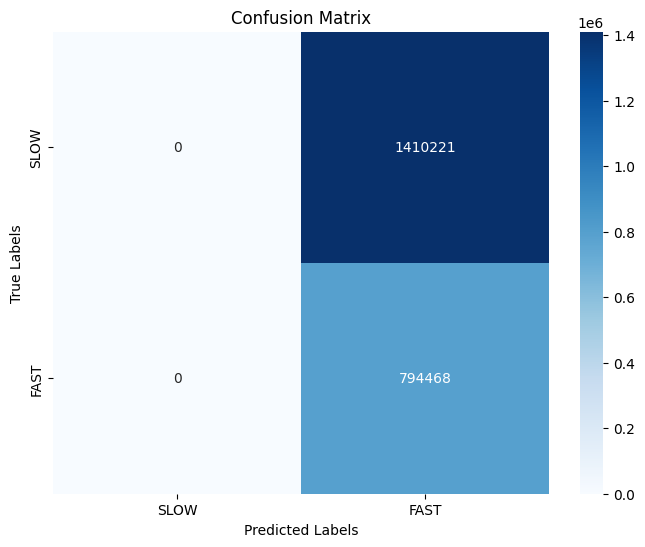

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
cm = confusion_matrix(y_true_indices, y_pred_indices)
# ConfusionMatrixDisplay(cm).plot()
# CLIST =  ["Fast/Failure", "Slow/Failure", "Fast/Success", "Slow/Success"]

CLIST =  ["SLOW", "FAST"]
# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=CLIST, yticklabels=CLIST)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()
# 

In [37]:
# print(np.sum([1 for y in y_true_indices if y == 1]))
total = np.sum(cm, axis=1)
print(total, np.sum(total))
print(cm)
# 0: 14022, 1: 35079, 2: 780448 1375238

[1410221  794468] 2204689
[[859868 550353]
 [110734 683734]]


In [38]:
# def loss_function(reconstructed_x, original_x):
#     return F.cross_entropy(reconstructed_x, original_x)

# # def train(model, data_loader, optimizer, device):
# folder_graph = './timeclasses/'
# device = "cpu"
# # fname = 'small_graphs.pth'
# files = os.listdir(folder_graph)
# files = [file for file in files if file.endswith('.pickle')]
# hC = 20
# inC = 40
# # total_loss = 0
# dataset = GraphDataset(folder_graph, files)
# dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=8)
# outchannels = 2
# model = GraphEncoderWithResidual(in_channels=inC, hidden_channels=hC, out_channels=outchannels).to(device)
# optimizer = optim.Adam(model.parameters(), lr=0.01)
# model.train()
# printlosses = []
# for data in dataloader:
#     optimizer.zero_grad()
#     # print(np.shape(data[0][0]), np.shape(data[1][0]), np.shape(data[2][0]))
#     embed = model(data[0][0].to(device), data[1][0].to(device))
#     # print('input: ', data[0][0])
#     # print('edges: ', data[1][0])
    
#     # print(len(data[0][0]))
#     loss = loss_function(embed, data[2][0].to(device)) #cosine_loss(data[1][0].to(device), embed)
#     # loss = focal_loss(embed, data[2][0].to(device)) #cosine_loss(data[1][0].to(device), embed)
#     loss.backward()
#     optimizer.step()
#     # total_loss += loss.item()
#     # printlosses.append(loss.detach().item())
#     # if len(printlosses)%10000 == 0:
#     #     printlosses = printlosses[-10000:]
#     #     print(np.sum(printlosses)/10000.0)
#     for i, j in zip(embed[0], data[2][0]):
#         print('embed: ', i)
#         print('labels: ', j)
#     print('loss: ', loss.item())
#     print('embed shape: ', np.shape(embed))
#     print('labels shape: ', np.shape(data[2][0]))
#     # embeddings.append(embed.detach())
#     # print(total_loss)/10.0
#     break


# return total_loss / len(data_loader), embeddings, origs


In [39]:
# model.train()
# printlosses = []
# for data in dataloader:
#     optimizer.zero_grad()
#     # print(np.shape(data[0][0]), np.shape(data[1][0]), np.shape(data[2][0]))
#     embed = model(data[0][0].to(device), data[1][0].to(device))
#     # print('input: ', data[0][0])
#     # print('edges: ', data[1][0])
    
#     # print(len(data[0][0]))
#     loss = loss_function(embed, data[2][0].to(device)) #cosine_loss(data[1][0].to(device), embed)
#     # loss = focal_loss(embed, data[2][0].to(device)) #cosine_loss(data[1][0].to(device), embed)
#     loss.backward()
#     optimizer.step()
#     # total_loss += loss.item()
#     # printlosses.append(loss.detach().item())
#     # if len(printlosses)%10000 == 0:
#     #     printlosses = printlosses[-10000:]
#     #     print(np.sum(printlosses)/10000.0)
#     for i, j in zip(embed, data[2][0]):
#         print('embed: ', i)
#         print('labels: ', j)
#         break
#     print('loss: ', loss.item())
#     print('embed shape: ', np.shape(embed))
#     print('labels shape: ', np.shape(data[2][0]))
#     # embeddings.append(embed.detach())
#     # print(total_loss)/10.0
#     break


In [2]:
# Example of target with class indices
# input = torch.randn(3, 5, requires_grad=True)
# target = torch.randint(5, (3,), dtype=torch.int64)
# loss = F.cross_entropy(input, target)
# loss.backward()
# print(np.shape(input), np.shape(target))
# import pickle
# fil2 = open('nodestime.pickle', 'rb')
# meta = pickle.load(fil2)
# fil2.close()


In [8]:
# import torch
# import statistics
# arr = []
# for a in meta:
#     arr.append(statistics.mean(meta[a]))



(0.0, 5000.0)

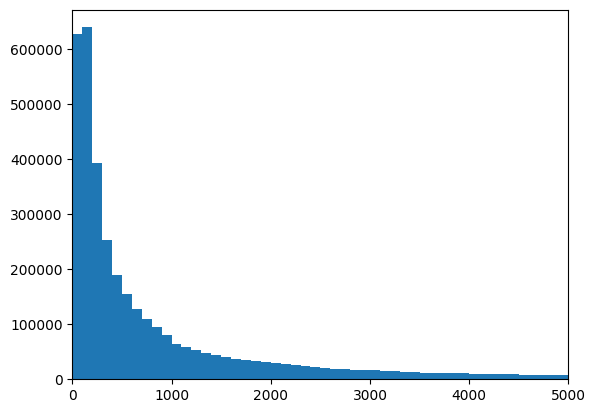

In [12]:
# arr[0]
# import matplotlib.pyplot as plt
# x=plt.hist(arr, bins=range(0,35000,100))
# plt.xlim([0,5000])

In [ ]:
# , bins=range(0,35000,200))
# plt.xlim([0,5000])

In [2]:
import pickle
fil2 = open('alledges.pickle', 'rb')
meta = pickle.load(fil2)
fil2.close()

In [5]:
for i in meta:
    print(i, meta[i])
    break

(0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0) defaultdict(<class 'int'>, {(0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0): 60047, (0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.833, 1.0, 1.0, 0.0): 6130, (0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.833, 1.0, 1.0, 0.0, 0.833, 1.0, 1.0, 0.0): 273, (0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 0.667, 1.0, 1.0, 0.0, 

In [12]:
def create_edge_list(graph):
    edge_list = []
    nodeIDs = dict()
    for id, node in enumerate(graph):
        nodeIDs[node] = id
    # Iterate over each node and its neighbors dictionary
    for node, neighbors in graph.items():
        # For each neighbor and its frequency
        for neighbor, _ in neighbors.items():
            # Create a list of the node and frequency and add to the edge list
            edge_list.append([nodeIDs[node], nodeIDs[neighbor]])
    return edge_list, nodeIDs

elist, nodeIDs = create_edge_list(meta)

In [10]:
import numpy as np
np.shape(elist)

(12746584, 2)

In [13]:
fil2 = open('nodeswithIDs.pickle', 'wb')
pickle.dump(nodeIDs, fil2)
fil2.close()

fil2 = open('edgeList.pickle', 'wb')
pickle.dump(elist, fil2)
fil2.close()